## Analysis of solver tolerance experiments

Authored 10/16

Analysis of the data gathered by running `run_tol_experiments.py`

In [163]:
import matplotlib.pyplot as plt
import pandas as pd

In [164]:
df = pd.read_csv('tol_experiments.csv')
print(df.columns)

Index(['net_size', 'experiment', 'abstol', 'reltol', 'vntol', 'trtol',
       'chgtol', 'max_err', 'l1_err', 'l2_err', 'Total elapsed time (seconds)',
       'elapsed time since last call (seconds)', 'Total DRAM available',
       'DRAM currently available', 'Maximum ngspice program size',
       'Current ngspice program size', 'Number of lines in the deck',
       'Netlist loading time', 'Subckt and Param expansion time',
       'Netlist parsing time', 'Nominal temperature', 'Operating temperature',
       'Total iterations', 'Transient iterations', 'Circuit Equations',
       'Circuit original non-zeroes', 'Circuit fill-in non-zeroes',
       'Circuit total non-zeroes', 'Transient timepoints',
       'Accepted timepoints', 'Rejected timepoints',
       'Total analysis time (seconds)', 'Matrix load time',
       'Matrix synchronize time', 'Matrix reorder time', 'Matrix factor time',
       'Matrix solve time', 'Transient analysis time', 'Transient load time',
       'Transient sync ti

In [184]:
SWEEP_FIELDS = ['abstol', 'reltol', 'vntol', 'trtol', 'chgtol']
ERR_FIELDS = ['max_err', 'l1_err', 'l2_err']
SIZES = df['net_size'].unique()

In [185]:
df[df['experiment'] == 'baseline']

,net_size,experiment,abstol,reltol,vntol,trtol,chgtol,max_err,l1_err,l2_err,...,Transient factor time,Transient solve time,Transient trunc time,Transient iterations for the last time point,AC analysis time,AC load time,AC sync time,AC factor time,AC solve time,success
0,4,baseline,1.000000e-12,0.001,0.000001,1,1.000000e-14,0.0,0.0,0.0,...,0.065,0.016,0.013,0,0,0,0,0,0,True
22,5,baseline,1.000000e-12,0.001,0.000001,1,1.000000e-14,0.0,0.0,0.0,...,0.102,0.012,0.021,0,0,0,0,0,0,True
44,10,baseline,1.000000e-12,0.001,0.000001,1,1.000000e-14,0.0,0.0,0.0,...,1.371,0.103,0.072,0,0,0,0,0,0,True
66,20,baseline,1.000000e-12,0.001,0.000001,1,1.000000e-14,0.0,0.0,0.0,...,14.592,0.628,0.314,0,0,0,0,0,0,True
88,30,baseline,1.000000e-12,0.001,0.000001,1,1.000000e-14,0.0,0.0,0.0,...,52.850,1.540,0.817,0,0,0,0,0,0,True


In [186]:
df[(df['net_size'] == 4) & ((df['experiment'] == 'trtol') | (df['experiment'] == 'baseline'))][['net_size', 'trtol', 'max_err', 'Total analysis time (seconds)', 'Transient iterations', 'Transient timepoints']]

,net_size,trtol,max_err,Total analysis time (seconds),Transient iterations,Transient timepoints
0,4,1,0.0,0.259,5861,2799
10,4,7,0.0,0.250,5861,2799
11,4,10,0.0,0.250,5861,2799
12,4,50,0.0,0.251,5861,2799
13,4,100,0.0,0.249,5861,2799


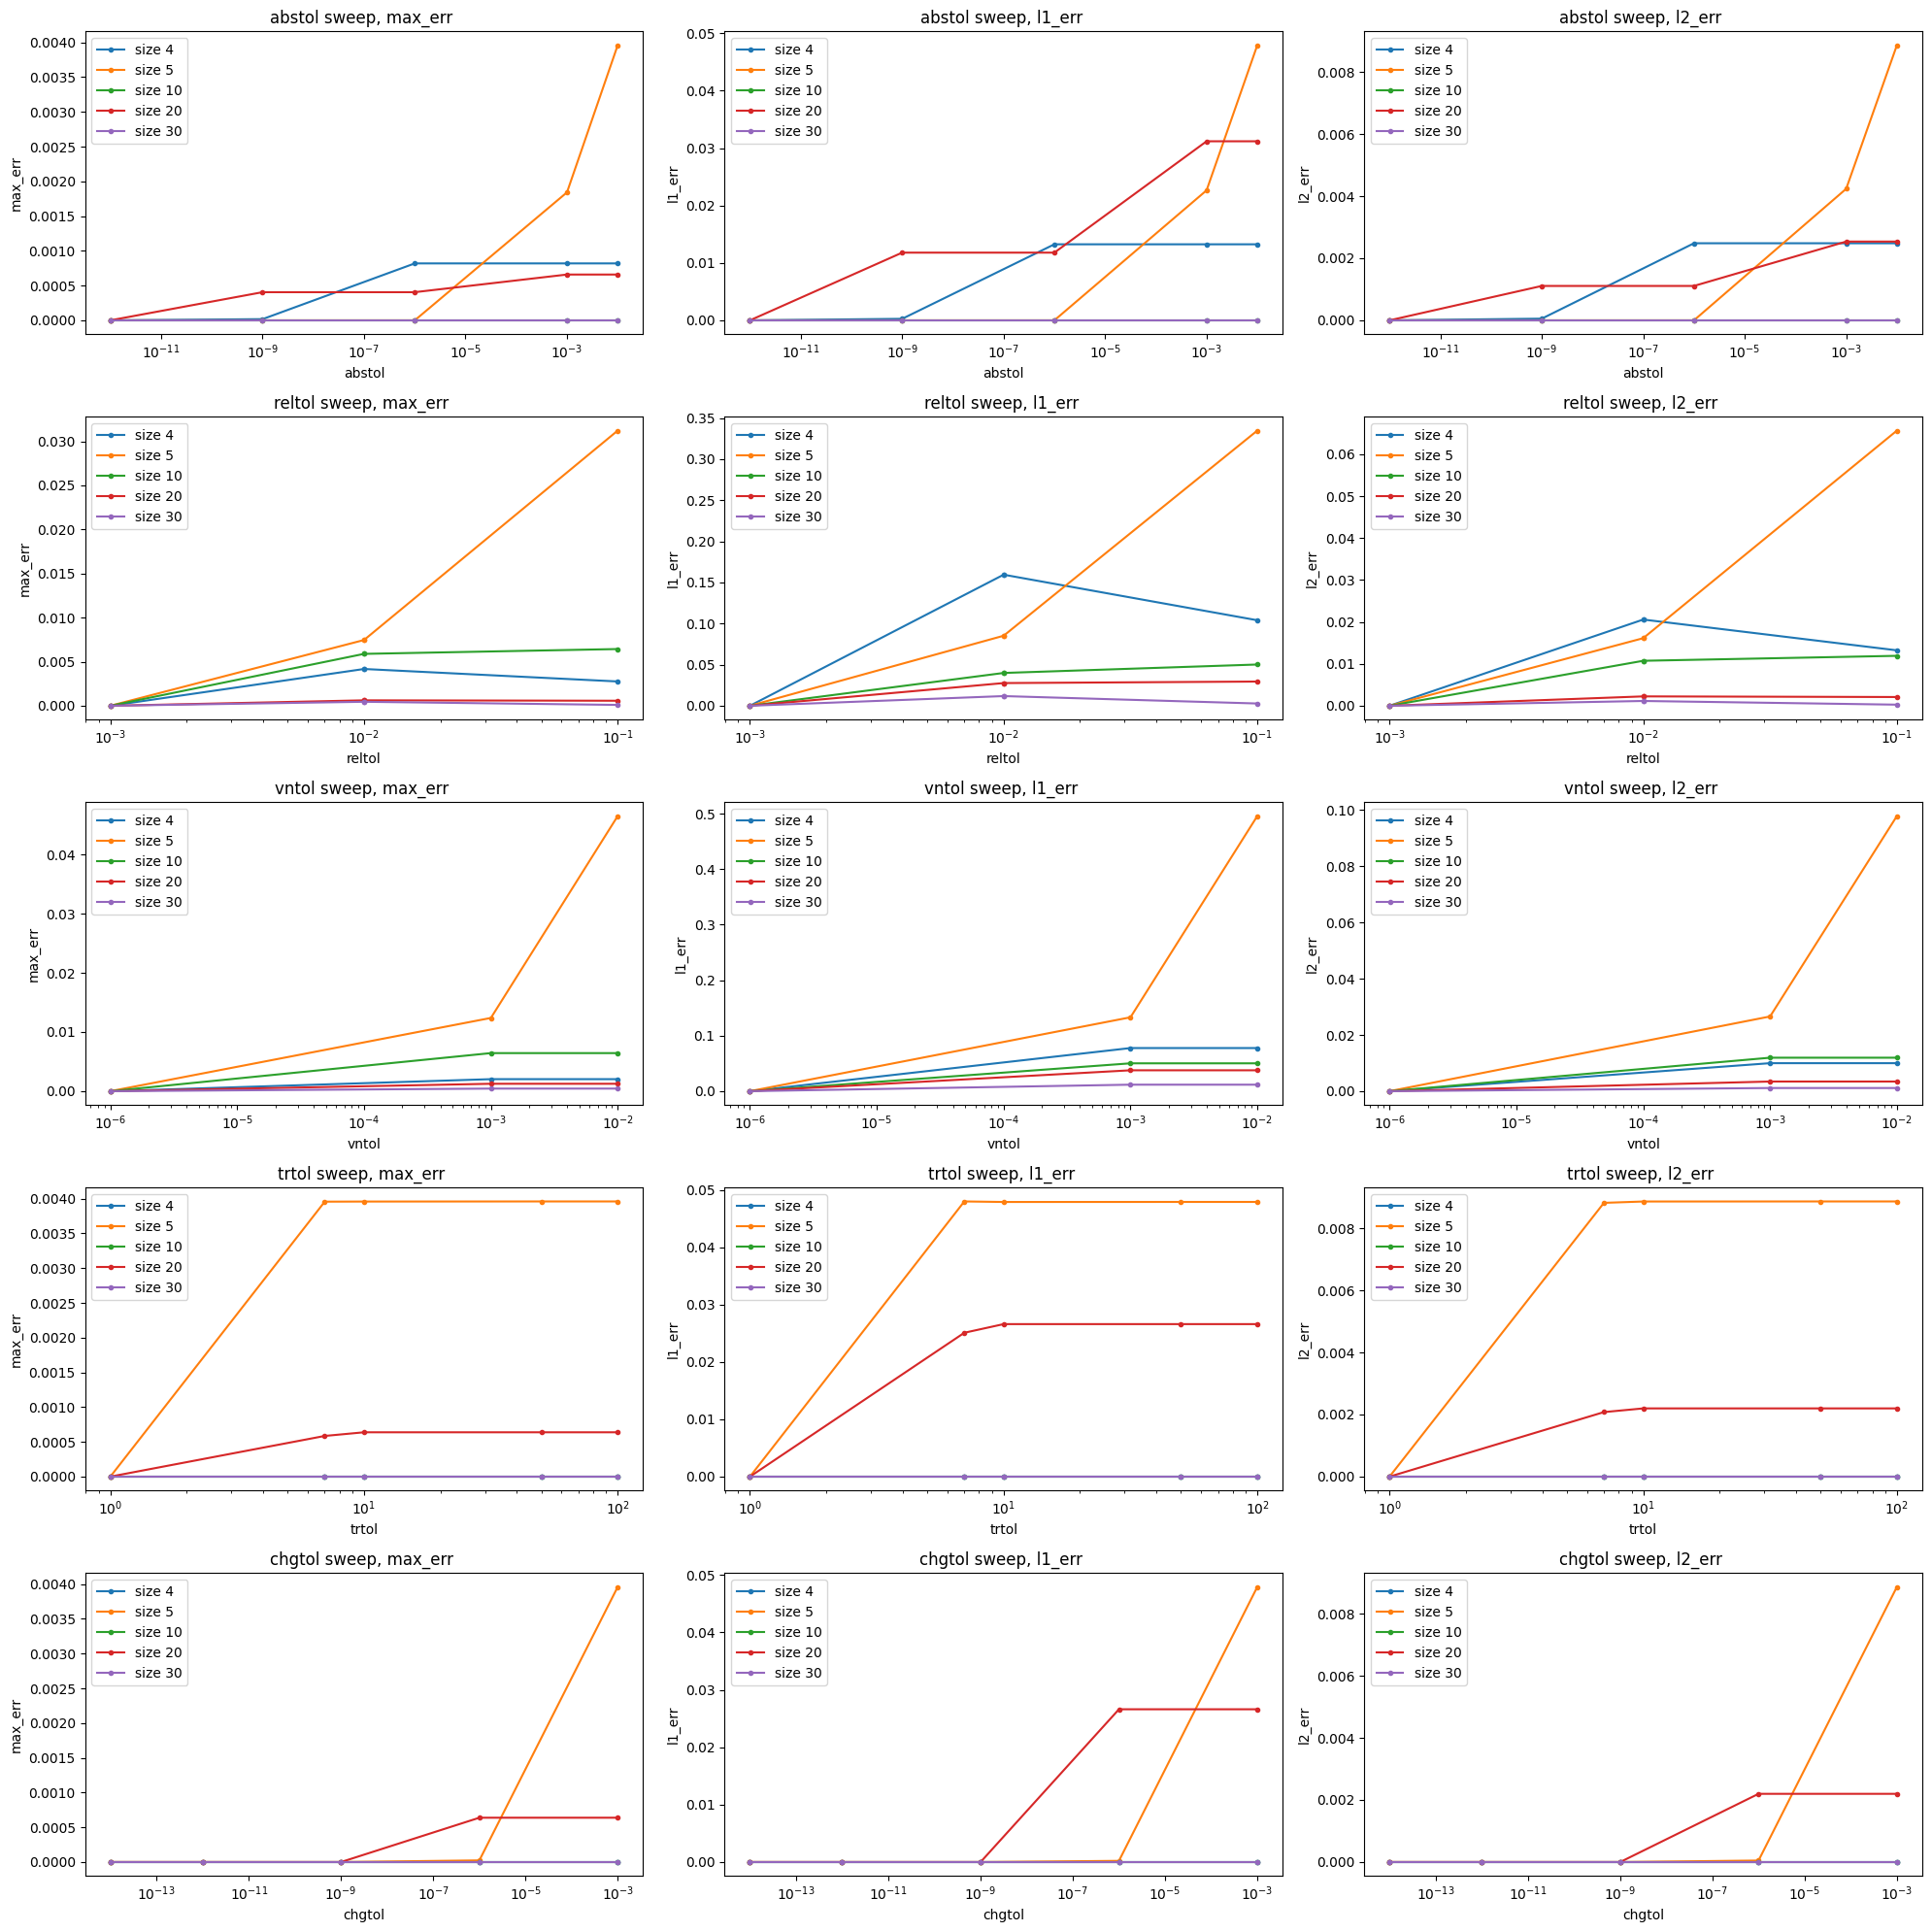

In [188]:
fig, axs = plt.subplots(len(SWEEP_FIELDS), len(ERR_FIELDS), figsize=(20, 20))

for field, row in zip(SWEEP_FIELDS + ['all'], axs):
    for size in SIZES:
        data = df[(df['net_size'] == size) & ((df['experiment'] == field) | (df['experiment'] == 'baseline')) & df['success']]
        for ax, err_field in zip(row, ERR_FIELDS):
            ax.plot(data[field], data[err_field], '.-', label=f'size {size}')
            ax.set_title(f'{field} sweep, {err_field} ')
            ax.set_xlabel(field)
            ax.set_ylabel(err_field)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.legend()

plt.tight_layout()

In [194]:
data

,net_size,experiment,abstol,reltol,vntol,trtol,chgtol,max_err,l1_err,l2_err,...,Transient factor time,Transient solve time,Transient trunc time,Transient iterations for the last time point,AC analysis time,AC load time,AC sync time,AC factor time,AC solve time,success
18,4,all,1.000000e-09,0.01,0.001,7,1.000000e-12,0.002016,0.077701,0.009961,...,0.057,0.015,0.007,0,0,0,0,0,0,True
19,4,all,1.000000e-06,0.01,0.010,10,1.000000e-09,0.002146,0.075973,0.009784,...,0.057,0.016,0.010,0,0,0,0,0,0,True
20,4,all,1.000000e-03,0.10,0.010,50,1.000000e-06,0.004221,0.158094,0.020148,...,0.061,0.013,0.013,0,0,0,0,0,0,True
21,4,all,1.000000e-02,0.10,0.010,100,1.000000e-03,0.004856,0.182141,0.023103,...,0.055,0.015,0.009,0,0,0,0,0,0,True
40,5,all,1.000000e-09,0.01,0.001,7,1.000000e-12,0.009125,0.102911,0.019615,...,0.124,0.023,0.015,0,0,0,0,0,0,True
41,5,all,1.000000e-06,0.01,0.010,10,1.000000e-09,0.042264,0.451859,0.088722,...,0.118,0.029,0.022,0,0,0,0,0,0,True
42,5,all,1.000000e-03,0.10,0.010,50,1.000000e-06,0.059566,0.641111,0.125470,...,0.114,0.022,0.018,0,0,0,0,0,0,True
43,5,all,1.000000e-02,0.10,0.010,100,1.000000e-03,0.065194,0.704106,0.137550,...,0.108,0.016,0.022,0,0,0,0,0,0,True
62,10,all,1.000000e-09,0.01,0.001,7,1.000000e-12,0.006619,0.053759,0.012334,...,1.358,0.118,0.063,0,0,0,0,0,0,True
63,10,all,1.000000e-06,0.01,0.010,10,1.000000e-09,0.006619,0.053759,0.012334,...,1.358,0.126,0.070,0,0,0,0,0,0,True


/var/folders/p1/kynpdwyn2r5fmbpnr8d45m340000gn/T/ipykernel_5710/796679769.py:23: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


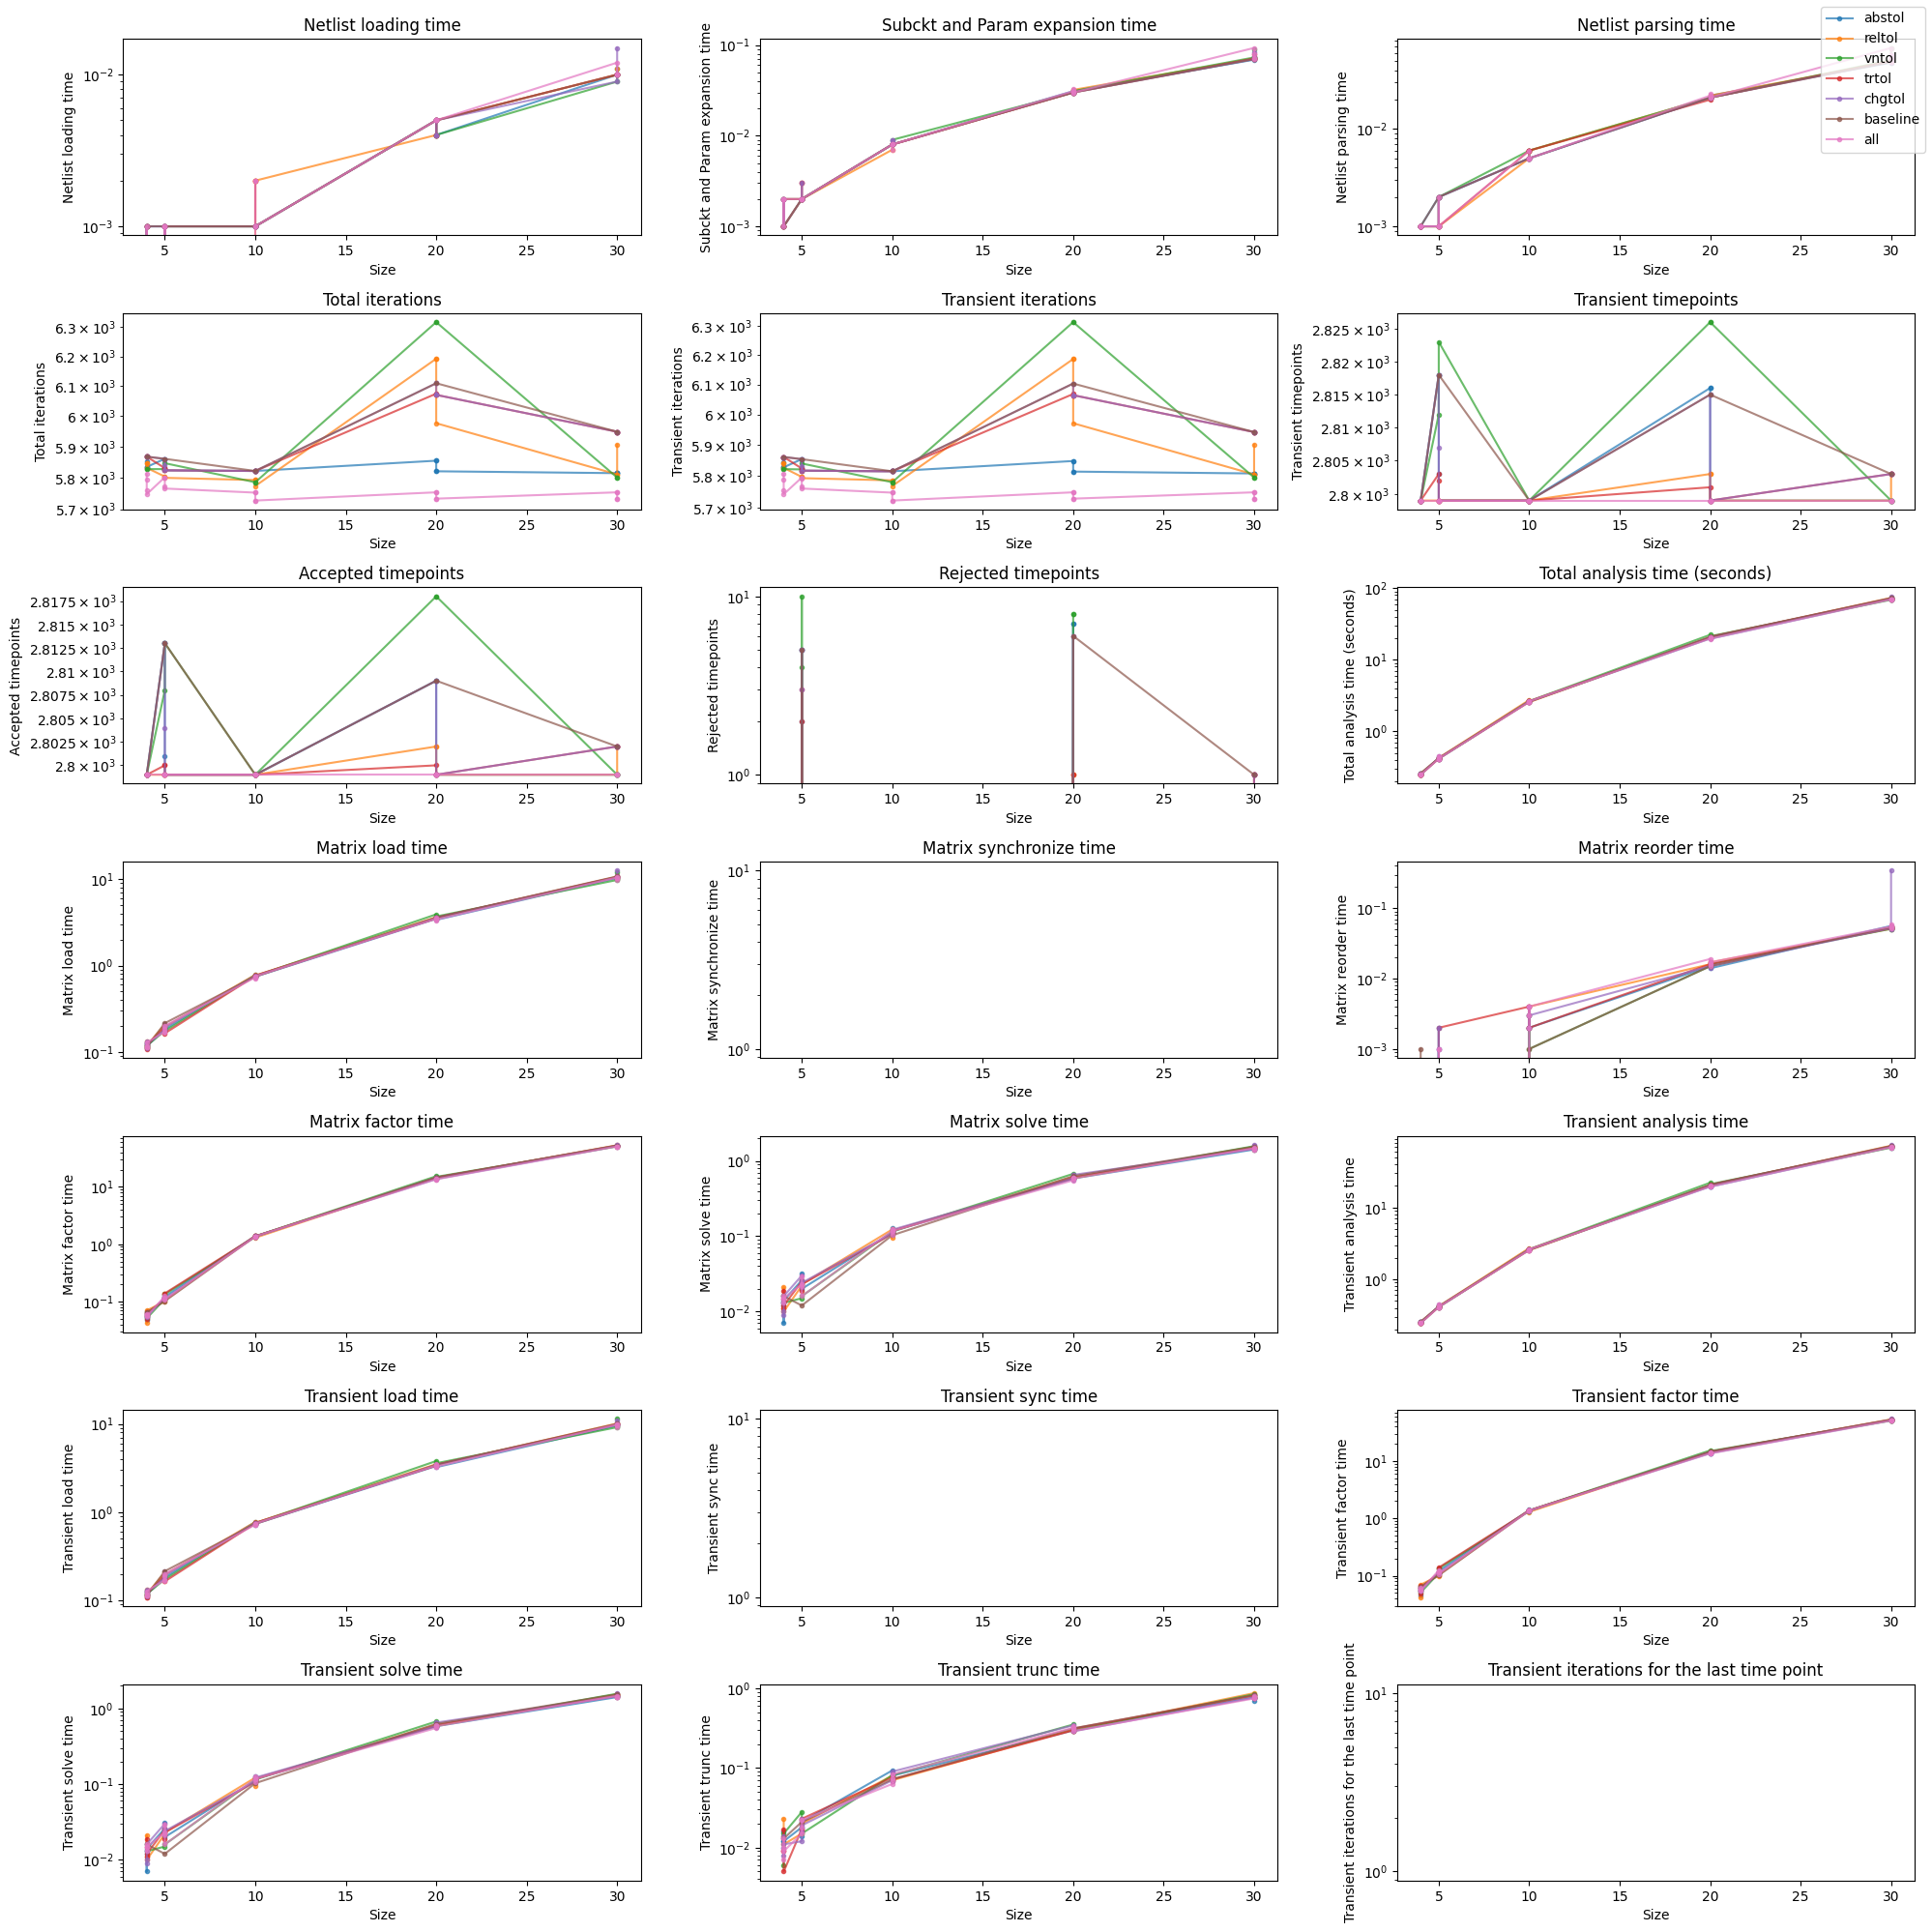

In [193]:
PLOT_FIELDS = ['Netlist loading time', 'Subckt and Param expansion time',
       'Netlist parsing time', 'Total iterations', 'Transient iterations',
       'Transient timepoints', 'Accepted timepoints', 'Rejected timepoints',
       'Total analysis time (seconds)', 'Matrix load time',
       'Matrix synchronize time', 'Matrix reorder time', 'Matrix factor time',
       'Matrix solve time', 'Transient analysis time', 'Transient load time',
       'Transient sync time', 'Transient factor time', 'Transient solve time',
       'Transient trunc time', 'Transient iterations for the last time point',]

fig, axs = plt.subplots(7, 3, figsize=(20, 20))

handles = []
for plot_field, ax in zip(PLOT_FIELDS, axs.flatten()):
    for experiment_field in SWEEP_FIELDS + ['baseline', 'all']:
        data = df[(df['experiment'] == experiment_field) & df['success']]
        lines = ax.plot(data['net_size'], data[plot_field], '.-', label=experiment_field, alpha=0.7)
        if plot_field == 'Total analysis time (seconds)':
            handles.append(lines[0])

    ax.set_title(plot_field)
    ax.set_xlabel('Size')
    ax.set_ylabel(plot_field)
    ax.set_yscale('log')
fig.legend(handles=handles, loc='upper right')
plt.tight_layout()